# Stellar Classification and Supervised Learning
This notebook demonstrates how to build, train, and evaluate multiple models (both traditional ML and PyTorch Neural Networks) using our custom `stellar_classification` package.

In [1]:
import sys
import os
import gc
import pandas as pd
import joblib
import matplotlib.pyplot as plt

#sistemare il warning di LightGBM fa creare warning a tutti gli altri modelli addestrati senza
#feature name, quindi meglio ingorarli
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Add the package root to sys.path so we can import stellar_classification
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'stellar_classification')))

import stellar_classification as sc

# Enable garbage collection
gc.enable()
gc.collect()

20

In [11]:
# Load dataset
data_path = '../stellar_classification/stellar_classification/data/star_classification.csv'
star = pd.read_csv(data_path)

print("First few rows:")
display(star.head())

print("\nData Info:")
star.info()

print("\nNull Values:")
print(star.isnull().sum())

print("\nClass Distribution:")
print(star["class"].value_counts(normalize=True) * 100)

# -------- Color indexes ----------
# star["u_g"] = star["u"] - star["g"]
# star["g_r"] = star["g"] - star["r"]
# star["r_i"] = star["r"] - star["i"]
# star["i_z"] = star["i"] - star["z"]

# star.info()


First few rows:


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842



Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  str    
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7)

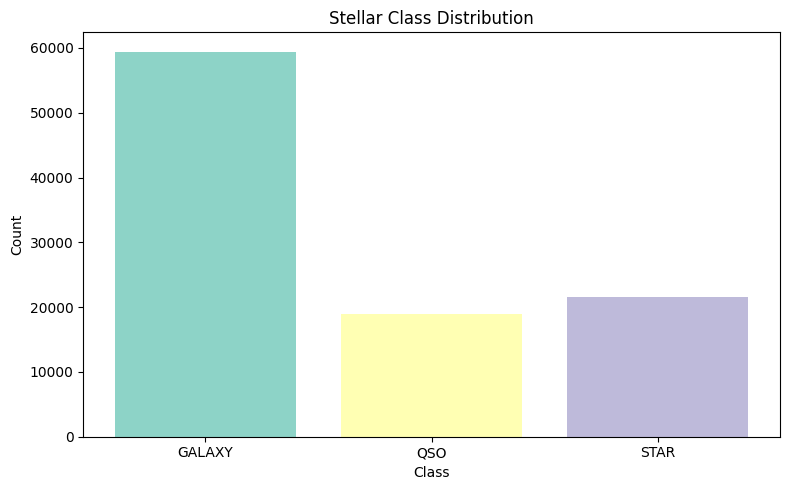

In [12]:
# Visualize Class Distribution
sc.plot_class_distribution(star['class'], title="Stellar Class Distribution")


Outliers removed: 9,400 rows  (90,600 remain)
X_train shape: (106419, 10)
X_val shape: (18120, 10)
X_test shape: (18120, 10)


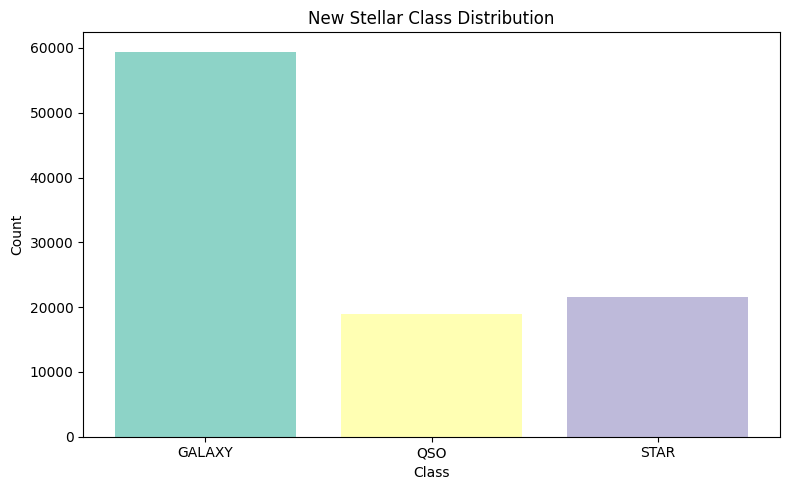

In [13]:
# Preprocessing: Apply outlier removal, splits, standardization, and SMOTE
X_train, X_val, X_test, y_train, y_val, y_test, label_encoder, scaler, feature_names = sc.prepare_splits(
    star, 
    target_col='class', 
    test_size=0.2, 
    val_ratio=0.25, 
    random_state=42, 
    apply_outlier_removal=True
)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")


In [14]:
# Convert numpy arrays to PyTorch DataLoaders
train_loader, val_loader, test_loader = sc.to_dataloaders(
    X_train, y_train, 
    X_val, y_val, 
    X_test, y_test, 
    batch_size=64
)

print("DataLoaders created.")


DataLoaders created.


In [ ]:
# Train and evaluate traditional ML models
models = sc.train_traditional(X_train, y_train, X_val, y_val)


In [16]:
# Train Voting Classifier utilizing the trained models and save it in trained_models directory
if os.path.exists('trained_models/voting_clf.pkl'):
    voting_clf = joblib.load('trained_models/voting_clf.pkl')
    print("Voting Classifier caricato da disco")
else:
    voting_clf = sc.train_voting(X_train, y_train, X_val, y_val, models=models)
    os.makedirs('trained_models', exist_ok=True)
    joblib.dump(voting_clf, 'trained_models/voting_clf_redshift.pkl')
    print("Voting Classifier trained and saved")


[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 106419, number of used features: 10
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 3050 Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 10 dense feature groups (1.22 MB) transferred to GPU in 0.001628 secs. 0 sparse feature groups
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
Voting Classifier trained.
  [Training] Acc=99.07%  P=0.99  R=0.99  F1=0.99
  [Validation] Acc=97.16%  P=0.95  R=0.96  F1=0.95
Voting Classifier trained and saved


In [20]:
# Train PyTorch Neural Network
import torch

input_size = X_train.shape[1]
num_classes = len(label_encoder.classes_)

nn_model = sc.train_neural(
    train_loader=train_loader,
    val_loader=val_loader,
    input_size=input_size,
    num_classes=num_classes,
    num_epochs=10,
    lr=0.001
)

#save the model in trained_models directory
torch.save(nn_model.state_dict(), 'trained_models/nn_model_redshift.pth')
print('model trained and saved')

Epoch  1/10  loss=0.2545  val_acc=93.71%
Epoch  2/10  loss=0.1619  val_acc=94.13%
Epoch  3/10  loss=0.1458  val_acc=94.19%
Epoch  4/10  loss=0.1376  val_acc=95.20%
Epoch  5/10  loss=0.1322  val_acc=94.97%
Epoch  6/10  loss=0.1280  val_acc=94.15%
Epoch  7/10  loss=0.1252  val_acc=95.12%
Epoch  8/10  loss=0.1229  val_acc=94.91%
Epoch  9/10  loss=0.1210  val_acc=95.81%
Epoch 10/10  loss=0.1191  val_acc=95.07%
model trained and saved


In [ ]:
# Base inference on test set
import torch 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

y_test_pred_voting = voting_clf.predict(X_test)
voting_metrics = sc.evaluate_test_set(y_test, y_test_pred_voting, "Voting Classifier")
sc.print_metrics(voting_metrics)

nn_metrics = sc.evaluate_neural(test_loader, nn_model, device, "Neural Network")
sc.print_metrics(nn_metrics)



In [ ]:
# Confusion Matrices
class_names = list(label_encoder.classes_)

sc.plot_confusion_matrix(voting_metrics['confusion_matrix'], class_names=class_names, title='Confusion Matrix - Voting Classifier')
sc.plot_confusion_matrix(nn_metrics['confusion_matrix'], class_names=class_names, title='Confusion Matrix - Neural Network')


In [ ]:
# Feature Importance (using permutation importance on the Voting Classifier)
#n_jobs decide quanti core usare, parti da 1 e monitora la ram, aumentalo un po alla volta (con 16 GB non oltre n_jobs=3)
#n_jobs è un parametro di permutation_importance di scikit-learn, leggete 
#la doc, non mettete n_jobs=-1 !!!!!!
imp = sc.compute_permutation_importance(voting_clf, X_test, y_test, feature_names=feature_names, n_jobs=6)
sc.plot_permutation_importance(imp, top_n=10)

print("Feature Importance Scores:")
for feat, val in imp.items():
    print(f"{feat}: {val:.4f}")
